In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the cleaned dataset
df = pd.read_csv("C:\\Users\\km120\\OneDrive\\Desktop\\FPL-Ai-Companion\\src\\data\\cleaned\\cleaned_fpl_playerstats_2024-25_with_form.csv")
df.head()


,id,player_cost,first_name,second_name,player_form,status,minutes,player_position,goals_scored,assists,...,red_cards,gw1_points,gw2_points,gw3_points,gw4_points,gw5_points,team_name,team_strength,total_points,form
0,1,5.4,Fábio,Ferreira Vieira,0.0,Unavailable,0,MID,0,0,...,0,0.0,0.0,0.0,0.0,0.0,Arsenal,5,0.0,0.000
1,2,6.8,Gabriel,Fernando de Jesus,0.3,Available,18,FWD,0,0,...,0,0.0,0.0,0.0,1.0,0.0,Arsenal,5,1.0,0.025
2,3,6.1,Gabriel,dos Santos Magalhães,8.0,Available,450,DEF,2,0,...,0,6.0,6.0,2.0,15.0,7.0,Arsenal,5,36.0,0.750
3,4,8.1,Kai,Havertz,4.0,Available,450,FWD,2,1,...,0,12.0,2.0,8.0,2.0,2.0,Arsenal,5,26.0,0.350
4,5,4.0,Karl,Hein,0.0,Unavailable,0,GKP,0,0,...,0,0.0,0.0,0.0,0.0,0.0,Arsenal,5,0.0,0.000


In [18]:
df1 = pd.read_csv("C:\\Users\\km120\\OneDrive\\Desktop\\FPL-Ai-Companion\\src\\data\\cleaned\\cleaned_merged_seasons_with_form.csv")

df1.head()

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,...,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW,form
0,2020-21,Aaron Connolly,FWD,Brighton,0,0,-3,0,0.3,78,...,32.0,1,0,0,0,55,True,0,1,0.100000
1,2020-21,Aaron Connolly,FWD,Brighton,0,2,27,1,11.3,78,...,23.0,8,-1161,5332,6493,55,False,0,2,0.450000
2,2020-21,Aaron Connolly,FWD,Brighton,0,0,2,0,12.1,78,...,8.0,2,13526,26823,13297,55,True,0,3,0.366667
3,2020-21,Aaron Connolly,FWD,Brighton,0,0,7,0,0.3,78,...,4.0,2,-1311,10399,11710,55,False,0,4,0.325000
4,2020-21,Aaron Connolly,FWD,Brighton,1,0,13,0,10.3,78,...,2.0,4,-8992,5860,14852,55,False,0,5,0.400000


In [15]:
# For df1 (multi-season dataset)
df1 = df1.sort_values(by=["name", "season_x", "GW"])
df1["form"] = (
    df1.groupby(["name", "season_x"])["total_points"]
        .transform(lambda x: x.rolling(window=4, min_periods=1).mean() / 10)
)

# For df (2024–25 dataset)
gw_cols = [col for col in df.columns if col.startswith("gw")]
df["form"] = df[gw_cols].apply(lambda row: row.tail(4).mean() / 10, axis=1)


In [ ]:
df1.to_csv(
    "C:\\Users\\km120\\OneDrive\\Desktop\\FPL-Ai-Companion\\src\\data\\cleaned\\cleaned_merged_seasons_with_form.csv",
    index=False
)


df.to_csv(
    "C:\\Users\\km120\\OneDrive\\Desktop\\FPL-Ai-Companion\\src\\data\\cleaned\\cleaned_fpl_playerstats_2024-25_with_form.csv",
    index=False
)


  position  total_points
0      FWD      1.569106
1      MID      1.453464
2      DEF      1.292225
3       GK      1.155998


C:\Users\km120\AppData\Local\Temp\ipykernel_34672\3338933834.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=position_points, x="position", y="total_points", palette="viridis")


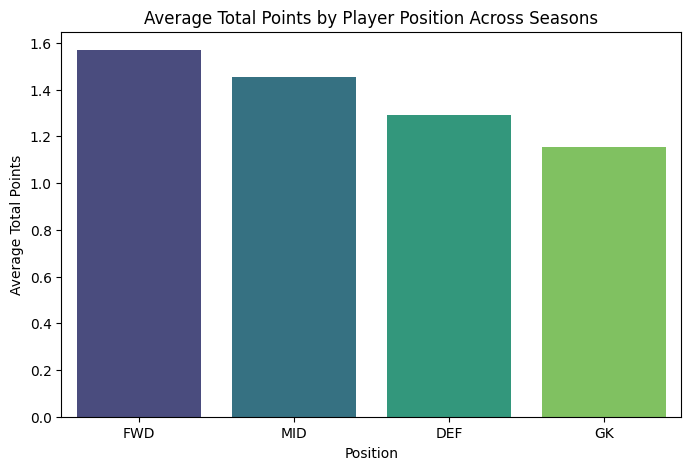

In [24]:
# Group by position and compute mean total points
position_points = (
    df1.groupby("position")["total_points"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

print(position_points)

# Visualization
plt.figure(figsize=(8, 5))
sns.barplot(data=position_points, x="position", y="total_points", palette="viridis")
plt.title("Average Total Points by Player Position Across Seasons")
plt.xlabel("Position")
plt.ylabel("Average Total Points")
plt.show()


Top 5 players by total points in 2022–23:
Index(['Erling Haaland', 'Harry Kane', 'Mohamed Salah', 'Martin Ødegaard',
       'Marcus Rashford'],
      dtype='object', name='name')


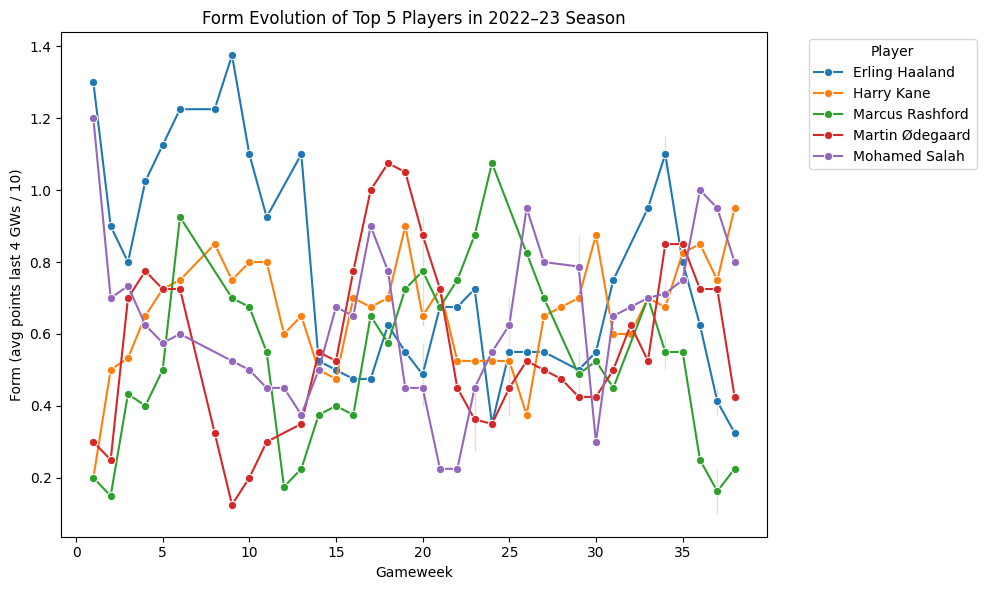

In [25]:
# Filter the 2022–23 season
season_df = df1[df1["season_x"] == "2022-23"]

# Get top 5 players by total points that season
top5 = (
    season_df.groupby("name")["total_points"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

print("Top 5 players by total points in 2022–23:")
print(top5)

# Filter only those players
top5_df = season_df[season_df["name"].isin(top5)]

# Plot form trend across gameweeks
plt.figure(figsize=(10, 6))
sns.lineplot(data=top5_df, x="GW", y="form", hue="name", marker="o")
plt.title("Form Evolution of Top 5 Players in 2022–23 Season")
plt.xlabel("Gameweek")
plt.ylabel("Form (avg points last 4 GWs / 10)")
plt.legend(title="Player", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [26]:
top5_form = (
    season_df.groupby("name")["form"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
)
print("Top 5 players by average form:")
print(top5_form)


Top 5 players by average form:
name
Erling Haaland              0.751316
Harry Kane                  0.660746
Mohamed Salah               0.642325
Martin Ødegaard             0.561842
Gabriel Martinelli Silva    0.551535
Name: form, dtype: float64
